In [3]:
# ============================================
# 1. Import Libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error , r2_score
from sklearn.model_selection import train_test_split, cross_val_score

In [4]:
# ============================================
# 2. Load & Explore Data (EDA)
# ============================================
df = pd.read_csv("Weather_Data.csv")
df.head(30)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
5,32.0,55,3.5,26.0,overcast,1010.03,2,Summer,5.0,inland,Cloudy
6,-2.0,97,8.0,86.0,overcast,990.87,1,Winter,4.0,inland,Snowy
7,3.0,85,6.0,96.0,partly cloudy,984.46,1,Winter,3.5,inland,Snowy
8,3.0,83,6.0,66.0,overcast,999.44,0,Winter,1.0,mountain,Snowy
9,28.0,74,8.5,107.0,clear,1012.13,8,Winter,7.5,coastal,Sunny


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  str    
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  str    
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  str    
 10  Weather Type          13200 non-null  str    
dtypes: float64(5), int64(2), str(4)
memory usage: 1.1 MB


In [6]:
df.isna().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [7]:
df["Temperature"].describe()

count    13200.000000
mean        19.127576
std         17.386327
min        -25.000000
25%          4.000000
50%         21.000000
75%         31.000000
max        109.000000
Name: Temperature, dtype: float64

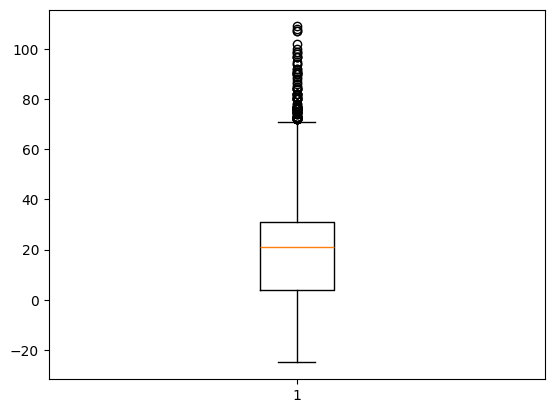

In [8]:
# Visualizing Outliers
plt.boxplot(df["Temperature"])
plt.show()

In [9]:
# --- Handling Outliers using IQR Method ---
Q1 = np.percentile(df["Temperature"], 25)
Q3 = np.percentile(df["Temperature"], 75)

IQR = Q3 - Q1

Lower = Q1 - 0.5 * IQR
Upper = Q3 + 0.5 * IQR

# Filtering the dataset
mask = (df["Temperature"] >= Lower) & (df["Temperature"] <= Upper)

df = df[mask]
df

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain,Rainy
13196,-1.0,76,3.5,23.0,cloudy,1067.23,1,Winter,6.0,coastal,Snowy
13197,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal,Cloudy
13198,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland,Snowy


In [10]:
print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
print(f"Min (Lower Bound): {Lower} | Max (Upper Bound): {Upper}")

Q1: 4.0 | Q3: 31.0 | IQR: 27.0
Min (Lower Bound): -9.5 | Max (Upper Bound): 44.5


In [11]:
# ============================================
# 3. Data Preprocessing
# ============================================
# One-Hot Encoding for categorical features
df = pd.get_dummies(df,columns=["Season","Location","Weather Type","Cloud Cover"],dtype="Float32")
df

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Season_Autumn,Season_Spring,Season_Summer,...,Location_inland,Location_mountain,Weather Type_Cloudy,Weather Type_Rainy,Weather Type_Snowy,Weather Type_Sunny,Cloud Cover_clear,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy
0,14.0,73,9.5,82.0,1010.82,2,3.5,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,39.0,96,8.5,71.0,1011.43,7,10.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,30.0,64,7.0,16.0,1018.72,5,5.5,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,38.0,83,1.5,82.0,1026.25,7,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,27.0,74,17.0,66.0,990.67,1,2.5,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,1003.15,1,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
13196,-1.0,76,3.5,23.0,1067.23,1,6.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
13197,30.0,77,5.5,28.0,1012.69,3,9.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
13198,3.0,76,10.0,94.0,984.27,0,2.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 12169 entries, 0 to 13199
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Temperature                12169 non-null  float64
 1   Humidity                   12169 non-null  int64  
 2   Wind Speed                 12169 non-null  float64
 3   Precipitation (%)          12169 non-null  float64
 4   Atmospheric Pressure       12169 non-null  float64
 5   UV Index                   12169 non-null  int64  
 6   Visibility (km)            12169 non-null  float64
 7   Season_Autumn              12169 non-null  Float32
 8   Season_Spring              12169 non-null  Float32
 9   Season_Summer              12169 non-null  Float32
 10  Season_Winter              12169 non-null  Float32
 11  Location_coastal           12169 non-null  Float32
 12  Location_inland            12169 non-null  Float32
 13  Location_mountain          12169 non-null  Float32
 14  Weathe

In [13]:
# Metrics Evaluation Function
def Calc_Reg_Metrics(y_test,y_pred):
    print("MSE:", mean_squared_error(y_test,y_pred))
    print("MAE:", mean_absolute_error(y_test,y_pred))
    print("RMSE:", root_mean_squared_error(y_test,y_pred))
    print("R2 Score:", r2_score(y_test,y_pred))

In [14]:
# Splitting features and target
X = df.drop("Temperature",axis=1)
y = df["Temperature"]

# Train-Test Split
X_train , X_test , y_train , y_test = train_test_split(X,y , test_size=0.2,shuffle=True,random_state=33)

In [15]:
# ============================================
# 4. Model Building using Pipeline
# ============================================

# Define the Pipeline: 
# 1. StandardScaler: Normalizes the data (Mean=0, Std=1)
# 2. GradientBoostingRegressor: The ML model
pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('regressor', GradientBoostingRegressor(
                        loss="squared_error",
                        n_estimators=100,
                        criterion="squared_error",
                        max_depth=3,
                        random_state=33
                                        ))
                                            ])

In [16]:
# Training the entire pipeline (Scaler + Model) in one go
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [17]:
# Cross Validation using the pipeline to ensure data consistency
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
print("CV Scores:", cv_scores)
print("Mean R2:", cv_scores.mean())

CV Scores: [0.68746466 0.68311314 0.70292836 0.69028124 0.67291099]
Mean R2: 0.6873396762808267


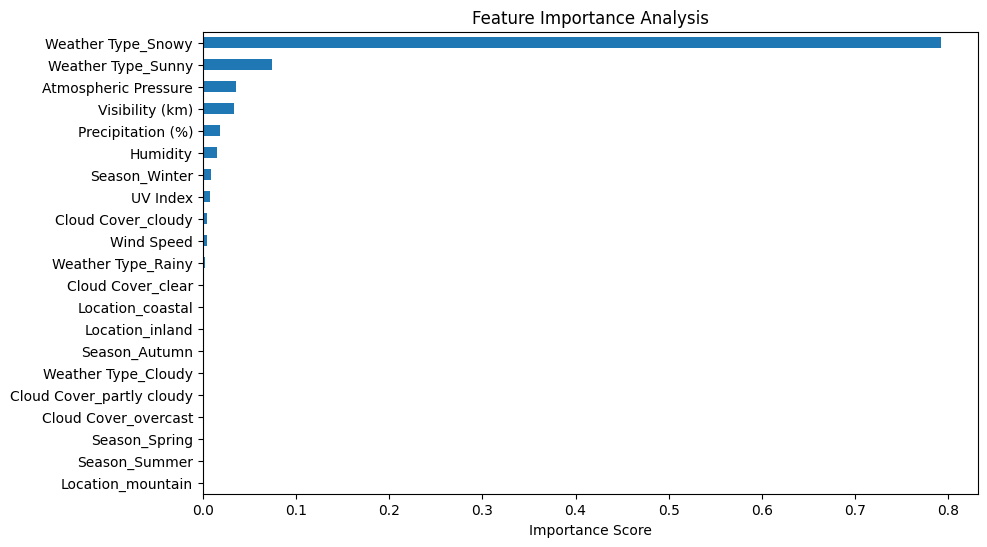

In [18]:
# Access the regressor from the pipeline to get feature importance
model_step = pipeline.named_steps['regressor']
importances = pd.Series(
    model_step.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

# Plotting Feature Importance
importances.plot(kind="barh", figsize=(10, 6), title="Feature Importance Analysis")
plt.xlabel("Importance Score")
plt.show()

In [19]:
# ============================================
# 5. Testing & Predictions
# ============================================

# Predicting using the pipeline (it will automatically scale the test data)
GBR_y_pred = pipeline.predict(X_test)

In [ ]:
# Display final evaluation metrics
print("\n--- Pipeline Regression Results ---")
Calc_Reg_Metrics(y_test, GBR_y_pred)

MSE: 63.10963031232489
MAE: 6.390145645888991
RMSE: 7.944156991923365
R2 Score: 0.694968117703306

Gradiant Boosting Regression: None
